# 14 · 손실·정규화·가중치 감쇠가 바꾸는 계산

**완성할 것:** 이상치가 있는 회귀에 MSE·MAE·Huber를 적용하고, 샘플 가중치와 L2의 미분을 직접 계산합니다. AdamW의 갱신과 dropout의 평균 효과를 작은 숫자로 확인합니다.

[01 미분](../00_기초/01_gradients_and_learning.ipynb), [02 관측 모형과 손실](../00_기초/02_probability_and_losses.ipynb), [04 optimizer](../00_기초/04_optimizers.ipynb)를 연결합니다.
[전체 경로](../../docs/CURRICULUM.md), [그림 보조 코드](../../src/utils/bridge_plots.py).

| 선택 | 바뀌는 자리 | 이 단원에서 확인할 것 |
|---|---|---|
| MSE·MAE·Huber | 잔차에서 손실과 기울기 | 큰 잔차의 영향 |
| 샘플 가중치 | 관측 기여의 평균 | 정규화 분모와 배치 미분 |
| L2 | 목적에 파라미터 제곱합 추가 | $\lambda W$ 기울기 |
| AdamW | 적응적 갱신과 별도의 감쇠 | 상태에 들어가는 기울기 |
| dropout | 학습 순전파에 무작위 mask | 고정 mask의 미분과 평균 목적 |

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.bridge_plots import plot_curves, plot_clouds, plot_bars
setup_plots()

'Noto Sans CJK KR'

## 1. 같은 잔차에 다른 비용 주기

잔차를 $r=\hat y-y$로 정합니다. 이 단원의 MSE 표기는 미분이 $r$인 **half-MSE**를 뜻합니다.

| 손실 $\rho(r)$ | 식 | 잔차에 대한 미분 |
|---|---|---|
| half-MSE | $r^2/2$ | $r$ |
| MAE | $\lvert r\rvert$ | $\operatorname{sign}(r)$ |
| Huber | $\lvert r\rvert\le\delta$에서 $r^2/2$, 그 밖에서 $\delta(\lvert r\rvert-\delta/2)$ | $\operatorname{clip}(r,-\delta,\delta)$ |

MAE의 $r=0$에서는 부분기울기 0을 선택합니다. 부분기울기는 꺾이는 점에서 사용할 수 있는 기울기의 집합이며, $\lvert r\rvert$의 0에서는 $[-1,1]$입니다.
Huber는 경계의 값과 1차 미분이 이어지도록 선형 부분을 정했습니다.
$\delta=.5$, $r=2$라면 세 손실은 각각 $2,2,.875$이고 미분은 $2,1,.5$입니다.

조건부 Gaussian의 고정 분산은 MSE, 조건부 Laplace의 고정 scale은 MAE에 대응합니다.
제곱 오차의 기대값은 조건부 평균에서, 절댓값 오차는 조건부 중앙값에서 최소화됩니다.
어떤 잔차를 얼마나 반영할지 관측 가정과 함께 고릅니다.

In [2]:
def element_loss(residual, kind, delta=.5):
    if kind == 'mse':
        return .5 * residual**2, residual
    if kind == 'mae':
        return np.abs(residual), np.sign(residual)
    if kind == 'huber' and delta > 0:
        magnitude = np.abs(residual)
        loss = np.where(magnitude <= delta, .5 * residual**2, delta * (magnitude - .5*delta))
        return loss, np.clip(residual, -delta, delta)
    raise ValueError('mse·mae·huber와 양의 delta를 사용합니다.')

In [3]:
for kind, expected_loss, expected_grad in [('mse', 2., 2.), ('mae', 2., 1.), ('huber', .875, .5)]:
    loss, grad = element_loss(np.array([2.]), kind, .5)
    np.testing.assert_allclose(loss, expected_loss)
    np.testing.assert_allclose(grad, expected_grad)
residual_axis = np.linspace(-3, 3, 301)
loss_curves = {name: element_loss(residual_axis, name)[0] for name in ['mse', 'mae', 'huber']}
gradient_curves = {name: element_loss(residual_axis, name)[1] for name in ['mse', 'mae', 'huber']}
print('손계산 통과: r=2, delta=0.5')

손계산 통과: r=2, delta=0.5


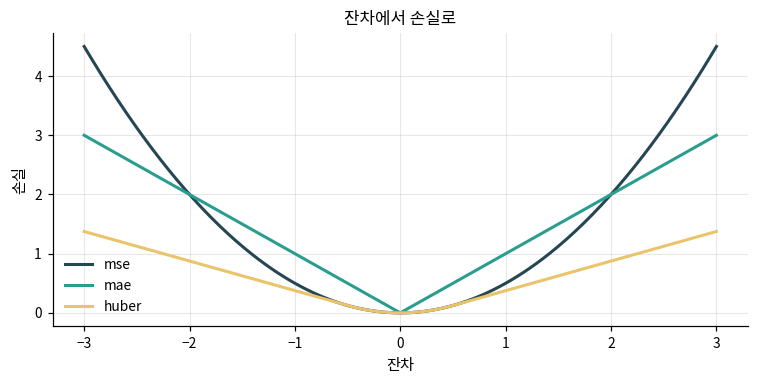

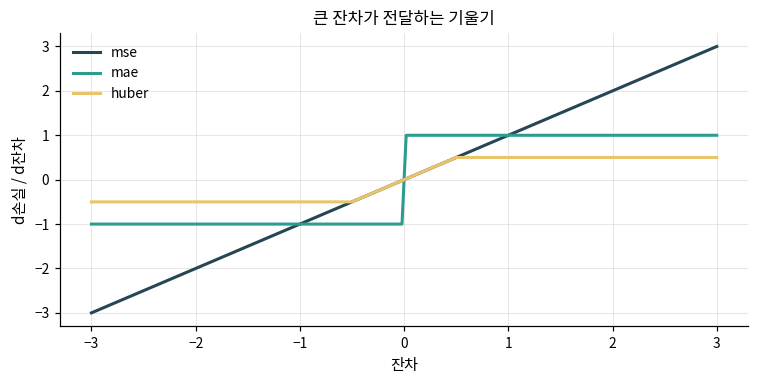

In [4]:
plot_curves(residual_axis, loss_curves, title='잔차에서 손실로', xlabel='잔차', ylabel='손실')
plot_curves(residual_axis, gradient_curves, title='큰 잔차가 전달하는 기울기', xlabel='잔차', ylabel='d손실 / d잔차')

MSE는 잔차가 커질수록 더 큰 기울기를 전달합니다. Huber의 $\delta$는 2차 구간의 폭과 선형 구간의 기울기를 함께 정합니다.
서로 다른 손실의 숫자 크기는 각자의 정의를 따릅니다. 모델 비교에는 같은 평가 지표를 적용합니다.

## 2. 관측 가중치와 평균 축

예측·정답이 $(N,K)$이고 관측 가중치가 $a:(N,)$일 때

$$L_{data}=\frac{\sum_na_n\left[\frac1K\sum_k\rho(r_{nk})\right]}{\sum_na_n},\qquad
\frac{\partial L_{data}}{\partial\hat Y_{nk}}=\frac{a_n}{K\sum_ma_m}\rho'(r_{nk}).$$

모든 가중치가 1이면 전체 원소 평균입니다. 모든 가중치에 같은 양수를 곱해도 목적은 같습니다.
`a[:, None]`는 `(N,1)`로 바꾸어 관측 가중치를 각 출력에 적용합니다.
가중치를 정하면 어떤 관측을 더 중요하게 다룰지도 함께 정한 것입니다.

In [5]:
def regression_loss(prediction, target, kind='huber', delta=.5, weights=None):
    if prediction.ndim != 2 or prediction.shape != target.shape:
        raise ValueError('예측과 정답을 같은 (N,K) 배열로 전달합니다.')
    N, K = prediction.shape
    weights = np.ones(N) if weights is None else np.asarray(weights, dtype=float)
    if weights.shape != (N,) or np.any(~np.isfinite(weights)) or np.any(weights < 0) or weights.sum() <= 0:
        raise ValueError('관측별 비음수 가중치이며 총합은 양수입니다.')
    values, derivatives = element_loss(prediction - target, kind, delta)
    normalized = weights[:, None] / (weights.sum() * K)
    return np.sum(normalized * values), normalized * derivatives

In [6]:
prediction = np.array([[.2, -.8], [1.5, -.1], [.7, -1.2]])
target = np.array([[0., .1], [.2, .3], [-.1, -.2]])
weights = np.array([1., 3., .5])
loss_gradient_errors = {}
for kind in ['mse', 'mae', 'huber']:
    value, grad = regression_loss(prediction, target, kind, .6, weights)
    numeric = numerical_gradient(lambda: regression_loss(prediction, target, kind, .6, weights)[0], prediction)
    loss_gradient_errors[kind] = rel_error(grad, numeric)
    np.testing.assert_allclose(regression_loss(prediction, target, kind, .6, weights*7)[0], value)
assert max(loss_gradient_errors.values()) < 1e-7
print('가중 손실 기울기 상대 오차:', loss_gradient_errors)

가중 손실 기울기 상대 오차: {'mse': 7.799658355076225e-11, 'mae': 1.3977802247034026e-10, 'huber': 1.1002213029520648e-10}


## 3. L2를 붙인 선형 모델의 전체 미분

$\hat Y=XW+b$, $J=L_{data}+\tfrac\lambda2\sum_{d,k}W_{dk}^2$를 정합니다.
가중치에 대한 벌점을 추가한 **정규화(regularization)** 입니다. 이 예제에서는 $b$를 벌점에서 분리합니다.

$dW=X^Td\hat Y+\lambda W$, $db=\sum_nd\hat Y_n$입니다.
$L_{data}$가 평균이므로 $\lambda W$는 배치 크기에 따라 다시 나누지 않고 사용합니다.
표본마다 다른 가중치와 정규화는 서로 다른 항이며 각각의 계수를 기록합니다.

In [7]:
def linear_objective(X, Y, W, b, kind='huber', delta=.5, weights=None, l2=0., loss_fn=regression_loss):
    data_loss, d_prediction = loss_fn(X @ W + b, Y, kind, delta, weights)
    objective = data_loss + .5 * l2 * np.sum(W**2)
    dW = X.T @ d_prediction + l2 * W
    db = d_prediction.sum(axis=0)
    return objective, dW, db


def fit_linear(X, Y, kind, delta=.5, weights=None, l2=0., steps=1200, lr=.04, loss_fn=regression_loss):
    W, b = np.zeros((X.shape[1], Y.shape[1])), np.zeros(Y.shape[1])
    history = []
    for step in range(steps):
        objective, dW, db = linear_objective(X, Y, W, b, kind, delta, weights, l2, loss_fn)
        history.append(objective)
        W -= lr * dW
        b -= lr * db
    history.append(linear_objective(X, Y, W, b, kind, delta, weights, l2, loss_fn)[0])
    return W, b, np.array(history)

In [8]:
rng = np.random.default_rng(140)
X_check, Y_check = rng.normal(size=(5, 3)), rng.normal(size=(5, 2))
W_check, b_check = rng.normal(size=(3, 2)), rng.normal(size=2)
weights_check = np.array([1., 0., 3., .2, 2.])
objective, dW, db = linear_objective(X_check, Y_check, W_check, b_check, weights=weights_check, l2=.3)
linear_gradient_errors = [rel_error(analytic, numerical_gradient(
    lambda: linear_objective(X_check, Y_check, W_check, b_check, weights=weights_check, l2=.3)[0], parameter))
    for analytic, parameter in [(dW, W_check), (db, b_check)]]
assert max(linear_gradient_errors) < 1e-7
print('가중 Huber + L2 전체 미분 상대 오차:', max(linear_gradient_errors))

가중 Huber + L2 전체 미분 상대 오차: 2.793343126683725e-10


### 완성 예제: 같은 이상치에 세 손실 적용하기

학습 관측 80개에 $y=2x+.4+\text{작은 잡음}$을 만들고 10개의 관측에 큰 양의 오차를 더합니다.
세 모델의 초기값·학습률·스텝을 같게 둡니다. 평가에는 별도로 만든 깨끗한 함수값의 **RMSE** $\sqrt{\operatorname{mean}(r^2)}$를 사용합니다.
이 데이터는 큰 오차의 영향을 관찰하기 위한 합성 예제입니다.

In [9]:
X_train = np.linspace(-1, 1, 80)[:, None]
Y_train = 2*X_train + .4 + rng.normal(size=(80, 1)) * .06
outlier_indices = np.arange(50, 70, 2)
Y_train[outlier_indices] += 7.
X_clean = np.linspace(-1.2, 1.2, 160)[:, None]
Y_clean = 2*X_clean + .4
models, rmse_by_loss = {}, {}
for kind in ['mse', 'mae', 'huber']:
    W, b, history = fit_linear(X_train, Y_train, kind, delta=.3)
    models[kind] = (W, b, history)
    rmse_by_loss[kind] = np.sqrt(np.mean((X_clean @ W + b - Y_clean)**2))
    print(kind, '기울기/절편:', W.item(), b.item(), '깨끗한 함수 RMSE:', rmse_by_loss[kind])
assert rmse_by_loss['huber'] < rmse_by_loss['mse']

mse 기울기/절편: 3.2527710951376916 1.2682392167877086 깨끗한 함수 RMSE: 1.2315210814748554
mae 기울기/절편: 1.9986202531645563 0.4130000000000003 깨끗한 함수 RMSE: 0.013035538756957222
huber 기울기/절편: 2.0571234851654476 0.4412893343627832 깨끗한 함수 RMSE: 0.057365453459457774


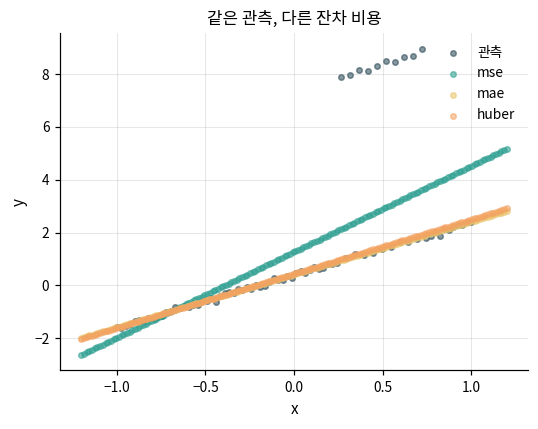

In [10]:
model_points = {kind: np.column_stack([X_clean, X_clean @ W + b]) for kind, (W, b, _) in models.items()}
plot_clouds([('같은 관측, 다른 잔차 비용', {'관측': np.column_stack([X_train, Y_train]), **model_points})],
            xlabel='x', ylabel='y', equal=False)

MSE는 큰 양의 오차를 줄이는 쪽으로 직선을 움직였습니다. Huber·MAE는 큰 잔차의 기울기를 제한합니다.
이 결과는 이 관측 생성 방식에서 비교한 수치입니다. 큰 값 자체가 예측 대상의 중요한 신호라면 그 관측 가정을 평가 데이터에도 반영합니다.

### L2의 계수와 해석해 비교

half-MSE 선형 모델에서 $A=[X,1]$, $\theta=[W;b]$를 쓰면
$(A^TA+NK\lambda P)\theta=A^TY$입니다. $P$는 $W$ 자리에 1, $b$ 자리에 0인 대각행렬입니다.
출력 수가 $K$이고 데이터 손실이 $NK$개 원소의 평균이므로 계수는 $NK\lambda$입니다. 아래 첫 비교는 $K=1$이며, 이어서 $K=2$도 검산합니다. 이것은 정규화된 최소제곱인 ridge의 해입니다. 기울기 학습이 같은 목적의 해로 가는지 대조합니다.

In [11]:
X_ridge = rng.normal(size=(60, 3))
Y_ridge = X_ridge @ np.array([[1.], [-2.], [.5]]) + .4 + rng.normal(size=(60, 1)) * .1
ridge_norms = []
for l2 in [0., .1, 1.]:
    W, b, _ = fit_linear(X_ridge, Y_ridge, 'mse', l2=l2, steps=1500)
    A = np.column_stack([X_ridge, np.ones(len(X_ridge))])
    penalty = np.diag([1., 1., 1., 0.])
    exact = np.linalg.solve(A.T @ A + len(A)*Y_ridge.shape[1]*l2*penalty, A.T @ Y_ridge)
    np.testing.assert_allclose(np.vstack([W, b]), exact, atol=1e-10)
    ridge_norms.append(np.linalg.norm(W))
print('lambda=0,0.1,1의 가중치 길이:', ridge_norms)
Y_multi = np.column_stack([Y_ridge[:, 0], -.3*Y_ridge[:, 0]+.7])
W_multi, b_multi, _ = fit_linear(X_ridge, Y_multi, 'mse', l2=.4, steps=2000)
exact_multi = np.linalg.solve(A.T @ A + len(A)*Y_multi.shape[1]*.4*penalty, A.T @ Y_multi)
np.testing.assert_allclose(np.vstack([W_multi, b_multi]), exact_multi, atol=1e-10)
print('K=2 ridge 해와 학습값의 최대 절대차:', np.max(np.abs(np.vstack([W_multi, b_multi])-exact_multi)))

lambda=0,0.1,1의 가중치 길이: [np.float64(2.275587957068822), np.float64(2.104915903400096), np.float64(1.2567949361416186)]
K=2 ridge 해와 학습값의 최대 절대차: 2.886579864025407e-15


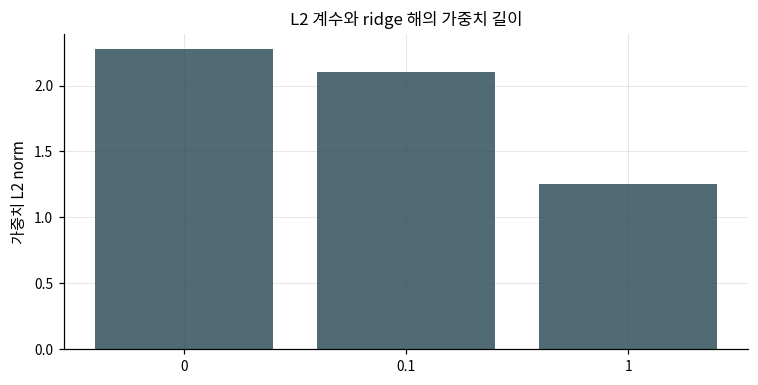

In [12]:
plot_bars(['0', '0.1', '1'], ridge_norms, title='L2 계수와 ridge 해의 가중치 길이', ylabel='가중치 L2 norm')

## 4. Adam의 L2와 AdamW의 감쇠를 한 스텝씩 보기

상태 없는 SGD에서는
$W-\eta(g+\lambda W)=(1-\eta\lambda)W-\eta g$입니다.
목적의 L2 기울기와 별도 가중치 감쇠가 같은 갱신을 만듭니다.

Adam에서 L2를 손실에 넣으면 $g+\lambda W$가 1차·2차 모멘트 상태 $m,v$에 들어갑니다.
**AdamW**는 데이터 기울기 $g$로 Adam 상태를 계산하고

$$W_{t+1}=(1-\eta\lambda)W_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}$$

로 갱신합니다. $\hat m_t=m_t/(1-\beta_1^t)$, $\hat v_t=v_t/(1-\beta_2^t)$이며 $t$는 1부터 시작합니다.
두 방법이 어디서 달라지는지 고정된 기울기 입력으로 확인합니다. 여기의 감쇠 계수 $\lambda$는 갱신 규약의 계수입니다.

In [13]:
def adam_step(W, gradient, state, lr=.03, beta1=.5, beta2=.75, eps=1e-8, weight_decay=0.):
    m, v, t = state
    t = t + 1
    m = beta1*m + (1-beta1)*gradient
    v = beta2*v + (1-beta2)*gradient**2
    m_hat, v_hat = m/(1-beta1**t), v/(1-beta2**t)
    updated = (1-lr*weight_decay)*W - lr*m_hat/(np.sqrt(v_hat)+eps)
    return updated, (m, v, t)

In [14]:
W0, gradient = np.array([1., 10.]), np.array([.2, -.1])
lr, decay = .03, .05
np.testing.assert_allclose(W0-lr*(gradient+decay*W0), (1-lr*decay)*W0-lr*gradient)
zero_state = (np.zeros(2), np.zeros(2), 0)
W_coupled, coupled_state = adam_step(W0, gradient+decay*W0, zero_state, lr=lr)
W_decoupled, decoupled_state = adam_step(W0, gradient, zero_state, lr=lr, weight_decay=decay)
expected_decoupled = (1-lr*decay)*W0-lr*gradient/(np.abs(gradient)+1e-8)
np.testing.assert_allclose(W_decoupled, expected_decoupled)
assert not np.allclose(W_coupled, W_decoupled)
np.testing.assert_allclose(decoupled_state[0], .5*gradient)
print('Adam + L2:', W_coupled, 'AdamW:', W_decoupled)

Adam + L2: [0.97 9.97] AdamW: [ 0.9685 10.015 ]


첫 스텝의 두 번째 좌표에서 L2를 포함한 기울기는 양수이고 데이터 기울기는 음수입니다. 상태에 무엇을 넣었는지가 갱신 방향에 드러납니다.

아래 손계산 검사는 서로 다른 $\beta_1,\beta_2$, 두 스텝, 작은 기울기, 큰 $\epsilon$을 사용합니다.
이 조건에서 bias correction·제곱근·epsilon 위치와 감쇠 적용을 함께 확인합니다.

In [15]:
test_w = np.array([1.2, -.7])
state = (np.zeros(2), np.zeros(2), 0)
manual_m, manual_v = np.zeros(2), np.zeros(2)
for t, g in enumerate([np.array([2., 1e-9]), np.array([-1., 2e-9])], start=1):
    manual_m = .5*manual_m + .5*g
    manual_v = .75*manual_v + .25*g*g
    expected = .98*test_w - .1*(manual_m/(1-.5**t))/(np.sqrt(manual_v/(1-.75**t))+.03)
    actual, state = adam_step(test_w, g, state, lr=.1, beta1=.5, beta2=.75, eps=.03, weight_decay=.2)
    np.testing.assert_allclose(actual, expected, atol=1e-14)
    test_w = actual
print('AdamW 두 스텝 손계산 통과:', test_w)

AdamW 두 스텝 손계산 통과: [ 1.05592828 -0.67228001]


## 5. dropout: mask를 고정해서 미분하고 평균으로 해석하기

각 원소에 대해 $M_{ij}\sim Bernoulli(q)$를 독립으로 뽑고
$\tilde H=H\odot M/q$로 계산합니다. $q$는 **유지 확률**입니다.
이것이 inverted dropout이며 $\mathbb E[\tilde H\mid H]=H$가 됩니다.
평가 단계에서는 $H$를 그대로 전달합니다. 학습 단계에 $1/q$ 배율을 적용한 규약입니다.

mask를 고정했을 때 $dH=G\odot M/q$입니다. 수치미분 중 같은 mask를 사용해야 같은 함수의 기울기를 비교하게 됩니다.
비선형 함수 $f$ 뒤에서는 일반적으로 $\mathbb E[f(\tilde H)]$와 $f(H)$가 달라집니다.

In [16]:
def dropout_forward(H, keep_probability, rng, training=True):
    if not 0 < keep_probability <= 1:
        raise ValueError('유지 확률 q는 0보다 크고 1 이하입니다.')
    if not training:
        return H.copy(), np.ones_like(H)
    multiplier = (rng.random(H.shape) < keep_probability).astype(float) / keep_probability
    return H * multiplier, multiplier


def dropout_backward(G, multiplier):
    return G * multiplier

In [17]:
H = np.array([[1., -2., .5], [3., .4, -1.]])
G = rng.normal(size=H.shape)
dropped, multiplier = dropout_forward(H, .7, rng)
dH = dropout_backward(G, multiplier)
dropout_error = rel_error(dH, numerical_gradient(lambda: np.sum(H*multiplier*G), H))
assert dropout_error < 1e-7
np.testing.assert_allclose(dropout_forward(H, .7, rng, training=False)[0], H)
np.testing.assert_allclose(dropout_forward(H, 1., rng)[0], H)
monte_carlo_output = np.stack([dropout_forward(H, .7, rng)[0] for _ in range(10000)]).mean(axis=0)
np.testing.assert_allclose(monte_carlo_output, H, atol=.07)
print('dropout 고정 mask 미분 오차:', dropout_error, '평균 출력 최대 절대차:', np.max(np.abs(monte_carlo_output-H)))

dropout 고정 mask 미분 오차: 1.9781313156190846e-10 평균 출력 최대 절대차: 0.005142857142903301


### 선형 모델의 제곱 손실에서는 평균 목적까지 계산할 수 있습니다

$\hat y=\sum_jW_jx_j+b$에 독립 dropout을 적용하면 예측의 평균은 원래 예측이고,
분산은 $\sum_jW_j^2x_j^2(1-q)/q$입니다.
$\mathbb E[(Z-y)^2]=(\mathbb E[Z]-y)^2+\operatorname{Var}(Z)$이므로

$$\mathbb E_M\left[\frac1{2N}\sum_n(\tilde y_n-y_n)^2\right]
=\frac1{2N}\sum_n(\hat y_n-y_n)^2
+\frac{1-q}{2q}\sum_jW_j^2\left[\frac1N\sum_nX_{nj}^2\right].$$

학습 입력을 평균 0·분산 1로 표준화했다면 대괄호는 1이고 L2 모양의 항을 얻습니다.
이 등식의 범위는 **입력에 독립 dropout을 적용한 선형 모델과 제곱 손실**입니다.
두 특성이면 mask가 네 종류여서 모든 경우의 확률을 곱하고 합해 정확히 검산할 수 있습니다.

In [18]:
X_two = np.array([[1., 2.], [-1., .5], [.2, -.4]])
y_two = np.array([.3, -.2, .7])
w_two, b_two, q_keep = np.array([.8, -.6]), .1, .7
masks = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
mask_probabilities = np.prod(np.where(masks == 1, q_keep, 1-q_keep), axis=1)
mask_losses = []
for mask in masks:
    prediction = (X_two * mask / q_keep) @ w_two + b_two
    mask_losses.append(.5*np.mean((prediction-y_two)**2))
exact_expected_loss = mask_probabilities @ np.array(mask_losses)
base_loss = .5*np.mean((X_two @ w_two + b_two - y_two)**2)
extra_loss = (1-q_keep)/(2*q_keep) * np.sum(w_two**2 * np.mean(X_two**2, axis=0))
np.testing.assert_allclose(mask_probabilities.sum(), 1.)
np.testing.assert_allclose(exact_expected_loss, base_loss+extra_loss, atol=1e-14)
print('dropout 평균 손실:', exact_expected_loss, '= 기본', base_loss, '+ 분산 항', extra_loss)

dropout 평균 손실: 0.3799904761904761 = 기본 0.17333333333333334 + 분산 항 0.20665714285714293


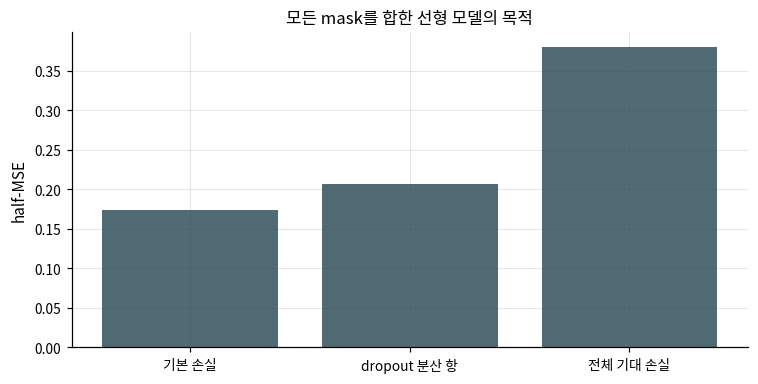

In [19]:
plot_bars(['기본 손실', 'dropout 분산 항', '전체 기대 손실'], [base_loss, extra_loss, exact_expected_loss],
          title='모든 mask를 합한 선형 모델의 목적', ylabel='half-MSE')

여기서는 관측별 손실의 기대값을 먼저 구해 평균했습니다. 합의 기댓값은 각 기댓값의 합이므로 관측마다 mask를 독립으로 뽑는 경우에도 같은 식이 됩니다.

## 6. 직접 바꾸기: 가중 Huber를 실제 학습에 연결하기

`my_regression_loss(prediction, target, kind, delta, weights)`를 작성해 `(loss, d_prediction)`을 반환해 보세요.
세 잔차 손실과 관측 가중치의 평균을 구현하고 아래 검사기에 전달합니다.
이후 `fit_linear(..., loss_fn=my_regression_loss)`로 실제 모델에 연결하고 $\delta=.1,.3,1$을 비교해 보세요.

In [20]:
def check_regression_loss(candidate):
    local_rng = np.random.default_rng(147)
    for N, K in [(2, 3), (5, 1)]:
        pred, target = local_rng.normal(size=(N, K)), local_rng.normal(size=(N, K))
        weights = np.arange(N, dtype=float)  # 가중치 0인 관측도 포함합니다.
        for kind in ['mse', 'mae', 'huber']:
            value, grad = candidate(pred.copy(), target.copy(), kind, .37, weights.copy())
            assert np.ndim(value) == 0 and np.shape(grad) == pred.shape
            reference, reference_grad = regression_loss(pred, target, kind, .37, weights)
            np.testing.assert_allclose(value, reference, atol=1e-12)
            np.testing.assert_allclose(grad, reference_grad, atol=1e-12)
            twice_value, twice_grad = candidate(np.repeat(pred, 2, axis=0), np.repeat(target, 2, axis=0), kind, .37, np.repeat(weights, 2))
            np.testing.assert_allclose(twice_value, value)
            np.testing.assert_allclose(twice_grad, np.repeat(grad, 2, axis=0)/2)
    X, Y = local_rng.normal(size=(6, 2)), local_rng.normal(size=(6, 2))
    W, b = local_rng.normal(size=(2, 2)), local_rng.normal(size=2)
    value, dW, db = linear_objective(X, Y, W, b, l2=.2, loss_fn=candidate)
    reference = linear_objective(X, Y, W, b, l2=.2)
    for actual, expected in zip((value, dW, db), reference):
        np.testing.assert_allclose(actual, expected, atol=1e-11)
    return '통과: 손실·출력 축·가중치·배치 반복·전체 모델'

In [21]:
print(check_regression_loss(regression_loss))
delta_results = {}
for delta in [.1, .3, 1.]:
    W, b, _ = fit_linear(X_train, Y_train, 'huber', delta=delta)
    delta_results[delta] = float(np.sqrt(np.mean((X_clean @ W+b-Y_clean)**2)))
print('delta별 깨끗한 함수 RMSE:', delta_results)

통과: 손실·출력 축·가중치·배치 반복·전체 모델


delta별 깨끗한 함수 RMSE: {0.1: 0.010562499617477515, 0.3: 0.057365453459457774, 1.0: 0.21613168053204956}


**준비도 확인**

- Huber의 선형 부분에 $-\delta^2/2$가 필요한 이유를 값과 미분으로 설명할 수 있나요?
- 관측 가중치의 합과 출력 개수가 각각 어느 미분에 들어가는지 쓸 수 있나요?
- 평균 데이터 손실과 L2의 계수를 정하고 ridge 해와 대조할 수 있나요?
- Adam + L2와 AdamW의 상태에 들어가는 값이 무엇인지 두 스텝으로 확인할 수 있나요?
- dropout의 고정 mask 미분·평균 출력·평균 손실을 각각 확인할 수 있나요?

다음 [15 실험과 평가](15_experiments_evaluation.ipynb)에서 데이터를 나누고 지표·반복 실험으로 이런 선택을 비교합니다.
BatchNorm·LayerNorm과 잔차 블록의 조합은 [확장 경로](../../docs/CURRICULUM.md)의 구조 조합 단원으로 이어집니다.

참고: [AdamW 원논문](https://arxiv.org/abs/1711.05101)의 분리된 가중치 감쇠,
[Dropout 원논문](https://jmlr.org/papers/v15/srivastava14a.html)의 무작위 unit 제거.